# Practical Session 5 - Parallel Markov chains with multiprocessing and dask

Students (pair):
- [Henry Fernandes--Strag](https://github.com/hfstrag)
- [Alexandre Torres--Leguet]([link](https://github.com/alxndrTL))

GitHub project where we collaborate: https://github.com/alxndrTL/python_sdia


**Useful references for this lab**:

[1] `seaborn`: [official tutorial](https://seaborn.pydata.org/tutorial.html)

[2] `multiprocessing`: [documentation](https://docs.python.org/3/library/multiprocessing.html), [doc2](https://he-arc.github.io/livre-python/multiprocessing/index.html)

[3] `dask`: [documentation](http://numba.pydata.org/) 

## <a name="content">Contents</a>
- [Exercise 1: seaborn, a useful tool for data visualisation](#ex1)
- [Exercise 2: Simulating a discrete-time homogeneous Markov chain](#ex2)
- [Bonus: Parallel computing with Dask](#bonus)
---

In [1]:
%load_ext autoreload
%autoreload 2

## <a name="ex1">Exercise 1: seaborn, a useful tool for data visualisation</a> [(&#8593;)](#content)
 
The `seaborn` package can significantly enhance data and data analysis visualization. See the [tutorial page](https://seaborn.pydata.org/tutorial.html) for examples of effective predefined graphics. An example aimed at visualizing the empirical distributions of 9 realizations of a bivariate Gaussian random vector is reported below.

/var/folders/4v/j98j235s7b30br93bwvc5ycm0000gn/T/ipykernel_51975/1573286285.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=x, y=y, cmap=cmap, shade=True, cut=5, ax=ax)
/var/folders/4v/j98j235s7b30br93bwvc5ycm0000gn/T/ipykernel_51975/1573286285.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=x, y=y, cmap=cmap, shade=True, cut=5, ax=ax)
/var/folders/4v/j98j235s7b30br93bwvc5ycm0000gn/T/ipykernel_51975/1573286285.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=x, y=y, cmap=cmap, shade=True, cut=5, ax=ax)
/var/folders/4v/j98j235s7b30br93bwvc5ycm0000gn/T/ipykernel_51975/1573286285.py:19: FutureWarning: 



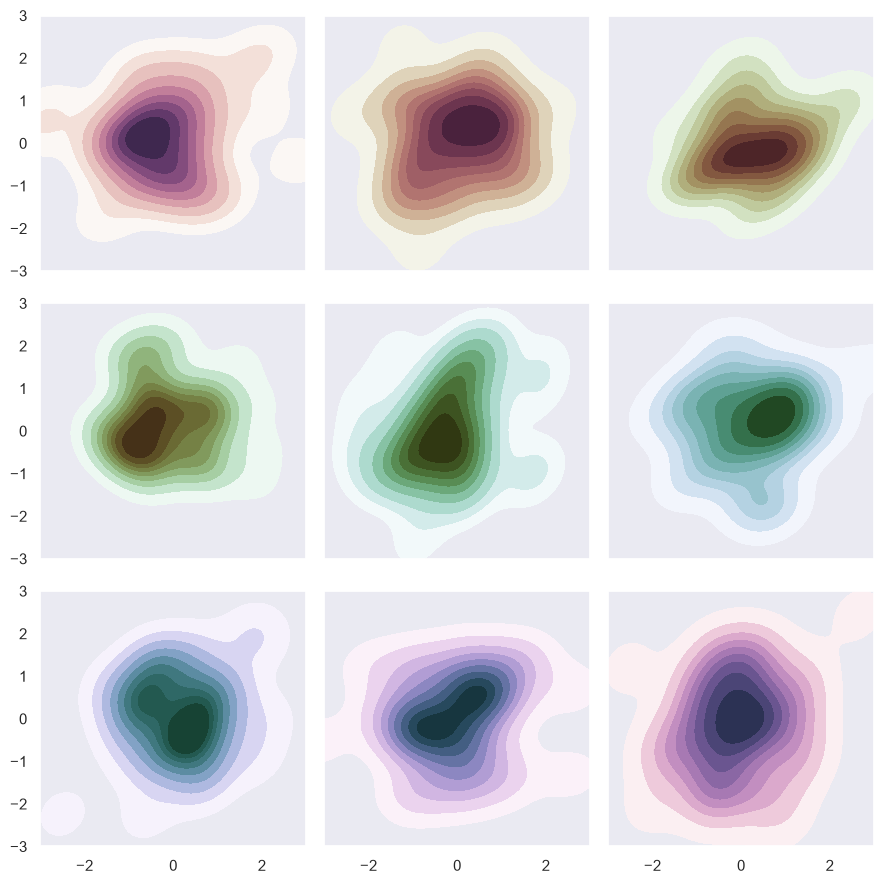

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(style="dark")
rng = np.random.default_rng(50)

# Set up the matplotlib figure
f, axes = plt.subplots(3, 3, figsize=(9, 9), sharex=True, sharey=True)

# Rotate the starting point around the cubehelix hue circle
for ax, s in zip(axes.flat, np.linspace(0, 3, 10)):

    # Create a cubehelix colormap to use with kdeplot
    cmap = sns.cubehelix_palette(start=s, light=1, as_cmap=True)

    # Generate and plot a random bivariate dataset
    x, y = rng.normal(size=(2, 50))
    sns.kdeplot(x=x, y=y, cmap=cmap, shade=True, cut=5, ax=ax)
    ax.set(xlim=(-3, 3), ylim=(-3, 3))

f.tight_layout()

1. Comment on the lines of codes related to the `seaborn` library to make their role explicit. More specifically comment on the KDE method.

**Answer:**

In [39]:
# 1ere ligne :
"""""
cmap = sns.cubehelix_palette(start=s, light=1, as_cmap=True)
"""

# on étudie sns.cubehelix_palette sur un cas simple
# d'abord, avec les arguments start et light

cmap = sns.cubehelix_palette(start=12, light=1)
cmap

[[1.0, 1.0, 1.0],
 [0.922327472861749, 0.7953497888490147, 0.7765272154048756],
 [0.8196681073029624, 0.5798464329142596, 0.643762396512992],
 [0.6533369503813297, 0.39502294342851785, 0.5557424760869683],
 [0.4193531769526402, 0.24367562711610177, 0.4370242752230857],
 [0.1750865648952203, 0.11840023306916847, 0.24215989137836513]]

In [20]:
# start modifie la couleur de départ (offset dans le spectre de couleurs)
# light modifie la luminosité

<Axes: >

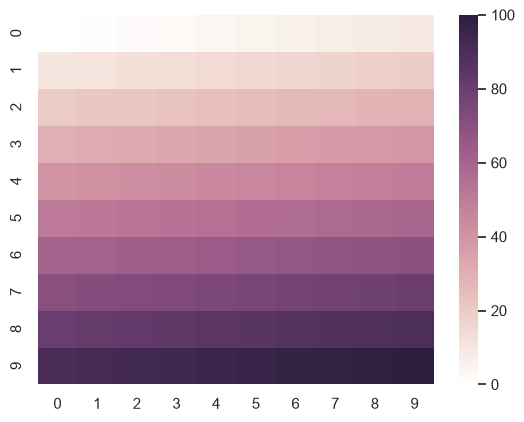

In [41]:
# on teste alors l'argument as_cmap=True
cmap = sns.cubehelix_palette(start=6, light=1, as_cmap=True)

# cela crée une colormap que l'on peut utiliser pour colorer des heatmaps
# chaque valeur de la matrice est associée à une couleur de la colormap
# cela crée donc un dégradé / gradient de couleurs en fonction des valeurs
data = np.linspace(0, 100, 100).reshape(10, 10)
sns.heatmap(data, cmap=cmap)

<Axes: ylabel='Density'>

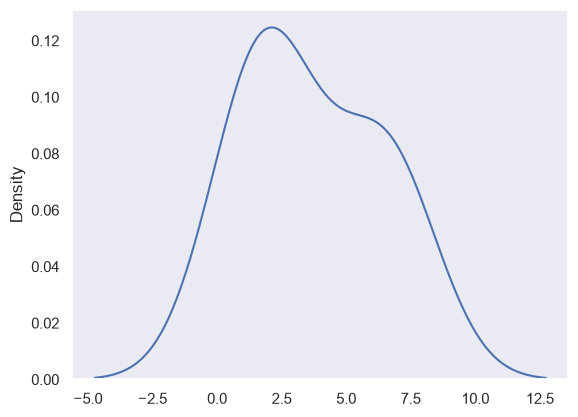

In [42]:
# 2e ligne :
"""
sns.kdeplot(x=x, y=y, cmap=cmap, shade=True, cut=5, ax=ax)
"""

# on commence par un exemple simple avec kdeplot, en 1D :

data = np.array([1, 2, 2.5, 6, 7])

sns.kdeplot(x=data)

# dans ce cas, kdeplot calcule et affiche une densité de probabilité (continue) à partir des valeurs de x
# on observe des pics autour de 2.5 et 6.5, qui correspond à la "masse" des valeurs de "data"
# c'est donc un histogramme lissé

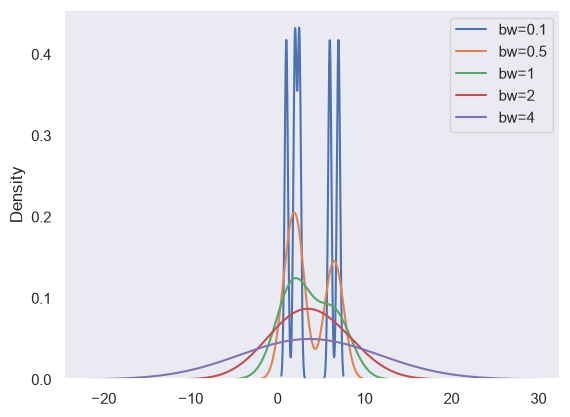

In [49]:
# on peut aussi jouer sur la bandwidth pour influer sur le lissage
bws = [0.1, 0.5, 1, 2, 4]
for bw in bws:
    sns.kdeplot(x=data, bw_adjust=bw, label=f"bw={bw}")
plt.legend()

# plus bw est petit, plus le lissage est faible = on a presque un histogramme
# plus c'est élevé, plus le lissage est fort

<Axes: >

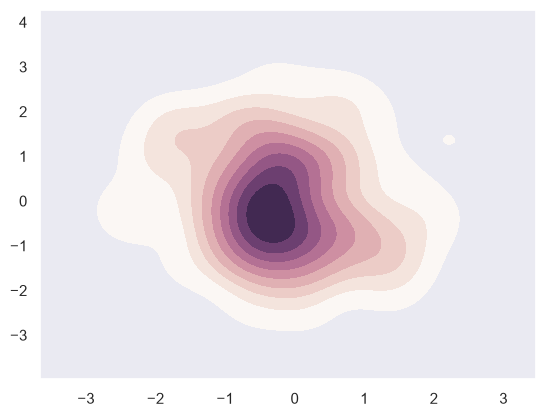

In [ ]:
# en 2D, en rajoutant la cmap calculée précédemment :
x, y = rng.normal(size=(2, 100))
sns.kdeplot(x=x, y=y, bw_adjust=1, fill=True, cmap=cmap)

In [ ]:
# en bref :
# - sns.cubehelix_palette permet de créer une palette de couleurs continues,
# qui sont utilisées pour affecter une couleur à une valeur

# - sns.kdeplot permet d'estimer et d'afficher une densité de probabilité (1D ou 2D) à partir d'un ensemble de valeurs


2. For one of the realizations, take a look at the documentation of [`sns.jointplot`](https://seaborn.pydata.org/examples/joint_kde.html) to display both the 2-D empirical distribution of the data, and 1D histograms of their distribution along each axis. 

**Answer:**

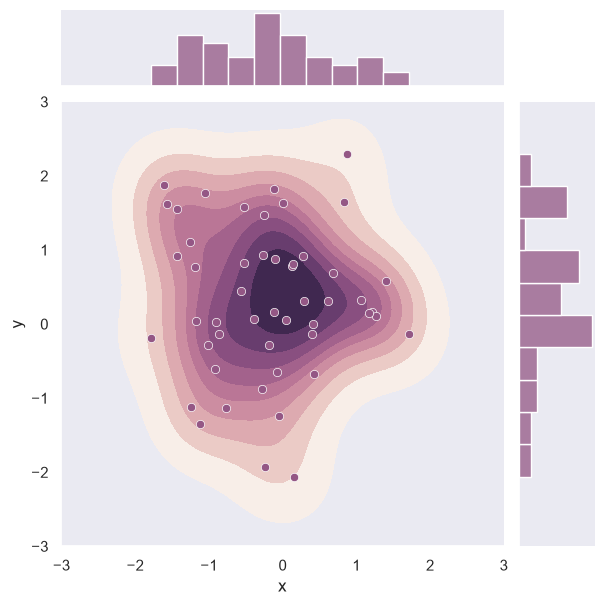

In [84]:
x, y = rng.normal(size=(2, 50))

cmap = sns.cubehelix_palette(start=0, light=1, as_cmap=True)

# sns.jointplot affiche les points dans l'espace (avec 'scatter')
# et les distributions sur les axes
g = sns.jointplot(x=x, y=y, kind="scatter", color=sns.cubehelix_palette(start=0)[3], marginal_kws=dict(bins=10), xlim=(-3, 3), ylim=(-3, 3))

# puis on utilise plot_joint pour ajouter par dessus le plot kdeplot vue en question 1
g.plot_joint(sns.kdeplot, fill=True, cmap=cmap, cut=5, zorder=0)

g.set_axis_labels("x", "y")

## <a name="ex2">Exercise 2: Simulating a discrete-time homogeneous Markov chain.</a> [(&#8593;)](#content)


Let ${(X_n)}_{n\geq 0}$ be a discrete-time homogeneous Markov chain with values over a finite ensemble $E=\{x_1,\dots,x_N\}$ identified to $\{1,\dots,N\}$. Consider $\boldsymbol{\rho} \in \Delta_N$, where $\Delta_N = \{\mathbf{x}\in\mathbb{R}^N \mid x_n \geq 0 \, \forall n \in \{1,\dotsc,N\} \text{ and } \sum_n x_n = 1 \}$ is the unit simplex in $\mathbb{R}^N$.

In the following, we consider the initial state of the chain $X_0$, following the discrete probability distribution:

$$
    \mathbb{P}(X_0 = k) = \rho_k, \qquad k \in \{1, \dots,  N\}.
$$
  
Let $\mathbf{A} = [a_{i,j}]_{i,j} \in \mathbb{R}^{N \times N}$ be the transition matrix of the chain, i.e.,

\begin{align*}
    &a_{i,j} = \mathbb{P}(X_{n+1} = j \mid X_{n} = i) \geq 0, \, \forall n \geq 0, \\
    &(\forall i \in \{1, \dotsc, N\}), \quad \sum_{j=1}^N a_{i,j} = 1.
\end{align*}
 
The chain is said to be homogeneous in that $\mathbf{A}$ does not depend from the time index $n$. Let $\tilde{a}_n$ represent the $n$-th row of $\mathbf{A}$. 

The trajectory of the chain can be simulated as follows:

>- Draw the discrete random variable $X_0$ with distribution $\boldsymbol{\rho}$;
>
>- For $q = 0$ to $n_{\text{iter}}-1$
>    - Draw the discrete random variable $X_{q+1}$ with distribution $\tilde{a}_{X_{q}}$;
>    
>- Return ${(X_q)}_{0 \leq q \leq n_{\text{iter}}}$.


<!-- If $X_n = k$, we know that $T$, the life time of the chain in the state $k$ obeys a geometric distribution with parameter $a_{kk}$. We also know that the probability of transition from k to $\ell\neq k$ is given by:

$$
    \mathbb{P}(X_{n+1}=\ell | X_n=k, \ell\neq k) = \frac{a_{k\ell}}{1-a_{kk}}.
$$

 ### One possible algorithm to simulate a Markov chain is therefore:

    a. generate the initial state $X_0$ according to the discrete law $\{\rho_1,\dots,\rho_N\}$.

    b. at instant $n$, knowing that $X_n=k$,

    i) determine the life time $T$ in state $X_n=k$ by simulating a geometrical variable with parameter $a_{kk}$. As a consequence $X_n = \dots = X_{n+T} = k$. When $T=0$, we simply still have $X_n=k$.

    ii) determine next transition instant $n+T$, and determine the next state by using the probabilities of transition. -->

1. Implement the above algorithm in a function `X = markov(rho,A,nmax,rng)` with:
     - `rho`: law of the initial state (nonnegative vector of size $N$, summing to 1),
     - `A`: transition matrix (of size $N\times N$) 
     - `nmax`: number of time steps,
     - `rng`: random number generator
     - `X`: trajectory of the chain.
     
In particular, check the input parameters `A` and `rho` make sense by adding appropriate assertions (or raising exceptions).
   - Examples : **transition matrix `A` should be square** ; **expected `A` to be a stochastic matrix** ; **verify if the size of `A` and `rho` are consistent** ; **verify if `rho` is in the unit simplex**
     - `np.allclose`, `np.isclose` and `np.all` could be useful

> Hints:
> - the function `np.random.choice` can be useful to draw discrete random variables.
> - use `states = np.arange(N)` to create the the labels of the states (from $0$ up to $N-1$)

Here is an example of execution : 
![alternatvie text](img/For_CourseM.png)

**Answer:**

In [131]:
def markov(rho, A, nmax, rng):
    assert A.ndim == 2 and (A.shape[0] == A.shape[1])       # A stochastique (taille de A : N x N)
    assert np.all(A >= 0)                                   # A stochastique (éléments >= 0)
    assert np.allclose(A.sum(axis=1), 1)                    # A stochastique (somme des lignes = 1)
    assert np.all(rho >= 0) and np.isclose(rho.sum(), 1)    # rho est une loi de prob.
    assert rho.shape == (A.shape[0],)                       # la taille de rho est cohérente avec A

    N = A.shape[0] # nombre d'états
    states = np.arange(N) # états possibles
    X = np.empty(nmax + 1, dtype=int)

    # premier état
    X[0] = rng.choice(states, p=rho)

    for q in range(nmax):
        # on échantillonne le prochain état via la distribution de proba
        # donnée par la ligne de la matrice A correspondant à l'état courant X
        X[q+1] = rng.choice(states, p=A[X[q]])

    return X

2. Set the random number generator to a known state. Make a few simulations using simple transition matrices (*i.e.*, taking any nonnegative matrix $A=(a_{i,j})$ such that its lines sum to 1) and display the trajectory of the chains.

**Answer:**

In [ ]:
def plot_markov(rho, A, nmax, rng, n_traj=3, offset=0.1):
    plt.figure(figsize=(8, 3))
    for k in range(n_traj):
        X = markov(rho, A, nmax, rng)
        plt.step(range(nmax + 1), X + k*offset, where="post", marker="o")
        # on rajoute un offset pour pouvoir différencier les courbes mêmes quand l'état est le même
    plt.yticks(range(A.shape[0]))
    plt.xlabel("n")
    plt.ylabel("état")
    plt.show()

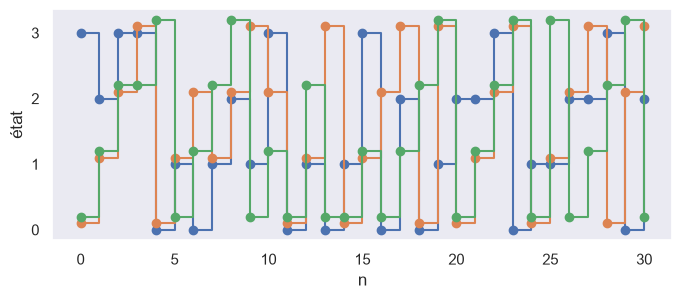

In [192]:
rng = np.random.default_rng(50)

# matrice stochastique 4x4 quelconque : tous les états communiquent

A = np.array([[0.1, 0.6, 0.2, 0.1],
              [0.2, 0.1, 0.6, 0.1],
              [0.1, 0.2, 0.1, 0.6],
              [0.6, 0.1, 0.2, 0.1]])
N = A.shape[0]
rho = np.ones(N) / N

plot_markov(rho, A, 30, rng, n_traj=3)

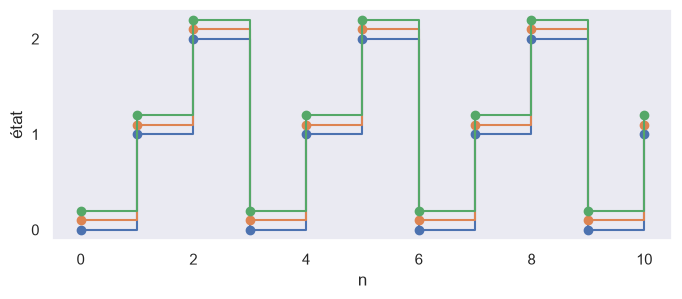

In [194]:
rng = np.random.default_rng(50)

# transitions déterministes, avec même distribution de départ

A = np.array([[0., 1., 0.],
              [0., 0., 1.],
              [1., 0., 0.]])
N = A.shape[0]
rho = np.zeros(N)
rho[0] = 1.0

plot_markov(rho, A, 10, rng, n_traj=3)

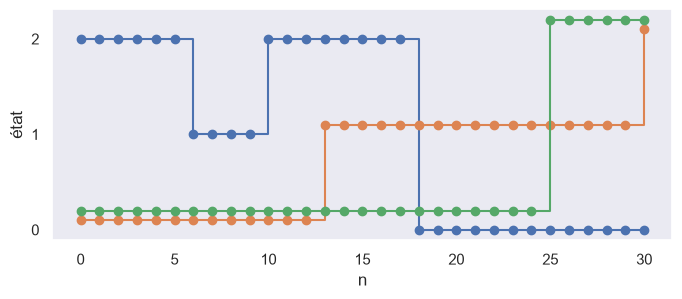

In [195]:
rng = np.random.default_rng(50)

# forte diagonale : la chaîne reste longtemps dans chaque état

A = np.array([[0.90, 0.05, 0.05],
              [0.05, 0.90, 0.05],
              [0.05, 0.05, 0.90]])
N = A.shape[0]
rho = np.ones(N) / N

plot_markov(rho, A, 30, rng, n_traj=3)

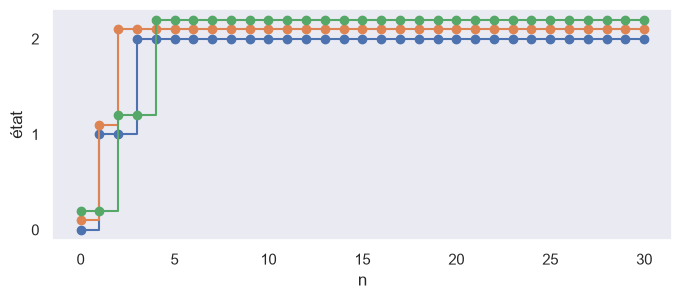

In [197]:
rng = np.random.default_rng(50)

# présence d'un état absorbant : une fois en 2, on n'en sort plus

A = np.array([[0.5, 0.5, 0.0],
              [0.3, 0.4, 0.3],
              [0.0, 0.0, 1.0]])
N = A.shape[0]
rho = np.zeros(N)
rho[0] = 1.0

plot_markov(rho, A, 30, rng, n_traj=3)

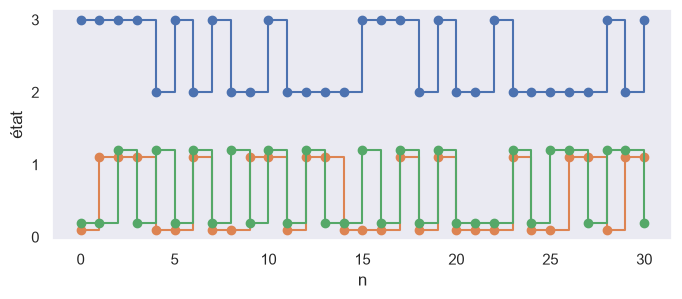

In [203]:
rng = np.random.default_rng(50)

# matrice par blocs, il y a donc deux chaînes indépendantes  (on reste là où on démarre)

A = np.array([[0.5, 0.5, 0.0, 0.0],
              [0.5, 0.5, 0.0, 0.0],
              [0.0, 0.0, 0.5, 0.5],
              [0.0, 0.0, 0.5, 0.5]])
N = A.shape[0]
rho = np.ones(N) / N

plot_markov(rho, A, 30, rng, n_traj=3)

3. Explore the potential of the [`multiprocessing` package](https://docs.python.org/3/library/multiprocessing.html) to simulate several Markov chains in parallel.

> Hint: the `mutiprocessing.Pool.starmap` or `mutiprocessing.Pool.starmap_async` methods could be useful.

**Answer:**

In [3]:
import numpy as np
import multiprocessing as mp
from markov import markov

A = np.array([[0.1, 0.6, 0.2, 0.1],
              [0.2, 0.1, 0.6, 0.1],
              [0.1, 0.2, 0.1, 0.6],
              [0.6, 0.1, 0.2, 0.1]])
N = A.shape[0]
rho = np.ones(N) / N

n_chains = 8
nmax = 20_000

rngs = np.random.default_rng(50).spawn(n_chains)
args = [(rho, A, nmax, r) for r in rngs]

with mp.Pool() as pool:
    trajs = pool.starmap(markov, args)

print(len(trajs), trajs[0][:10])

8 [2 1 2 3 0 1 2 3 0 1]


In [ ]:
import time
import matplotlib.pyplot as plt

def speedup(rho, A, nmax, n_chains):
    """ Fonction qui retourne l'acceleration apportée par la parallélisation de multiprocessing """
    
    # sequentiel
    rngs = np.random.default_rng(50).spawn(n_chains)
    args = [(rho, A, nmax, r) for r in rngs]
    t0 = time.perf_counter()
    [markov(*a) for a in args]
    t_seq = time.perf_counter() - t0

    # parallel
    rngs = np.random.default_rng(50).spawn(n_chains)
    args = [(rho, A, nmax, r) for r in rngs]
    t0 = time.perf_counter()
    with mp.Pool() as pool:
        pool.starmap(markov, args)
    t_par = time.perf_counter() - t0

    return t_seq / t_par

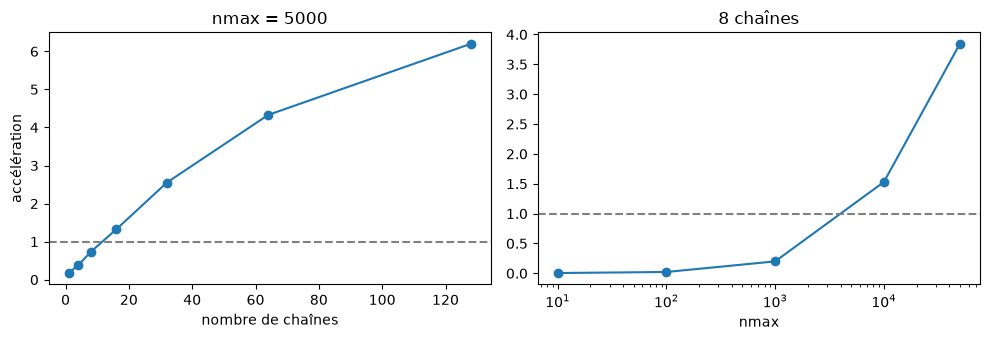

In [19]:
# on va étudier l'accélération apportée par la parallélisation en fonction de :
# - du nombre de chaînes
# - de la longueur de la chaîne

chains_list = [1, 4, 8, 16, 32, 64, 128]
nmax_list = [10, 100, 1_000, 10_000, 50_000]

acc_chains = [speedup(rho, A, 5_000, n) for n in chains_list]
acc_nmax = [speedup(rho, A, nmax, 8) for nmax in nmax_list]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.plot(chains_list, acc_chains, marker="o")
ax1.axhline(1, color="gray", ls="--")
ax1.set_xlabel("nombre de chaînes")
ax1.set_ylabel("accélération")
ax1.set_title("nmax = 5000")

ax2.plot(nmax_list, acc_nmax, marker="o")
ax2.axhline(1, color="gray", ls="--")
ax2.set_xscale("log")
ax2.set_xlabel("nmax")
ax2.set_title("8 chaînes")

plt.tight_layout()
plt.show()

In [ ]:
# on observe que :
# - à mesure qu'on augmente le nombre de chaînes, l'accélération augmente. au bout d'un certain temps les gains plafonnent 
# dû au fait qu'on atteint le nombre de coeurs disponibles sur la machine, on ne peut plus paralléliser

# - à mesure qu'on augmente la longueur de la chaîne, l'accélération augmente.

4. [Bonus] Generate Markov chains in parallel with the [`dask`](https://docs.dask.org/en/latest/futures.html) library, which offers more general parallelization functionalities (with, for instance, the use of [`Futures`](https://docs.dask.org/en/stable/futures.html), see tutorial [here](https://tutorial.dask.org/05_futures.html)). A useful example is provided [here](https://stackoverflow.com/questions/41471248/how-to-efficiently-submit-tasks-with-large-arguments-in-dask-distributed). Note that `dask` is much more versatile and powerful than `multiprocessing`, and can be useful to scale algorithms over multiple cores and/or computing nodes.

**Answer:**

In [ ]:
# your code

## <a name="bonus">Bonus: Parallel computing with Dask</a> [(&#8593;)](#content)

1. Take a look at the [`dask.array` documentation](https://docs.dask.org/en/stable/array-best-practices.html) and the associate [tutorial](https://tutorial.dask.org/02_array.html). Apply some of the functions introduced herein and in the [documentation](https://docs.dask.org/en/stable/array-best-practices.html) to parallelize the computation of the total variation investigated during session 2. Note that you can combine `dask` and `numba` to obtain an overall more efficient implementation. Note that timing can be worse than Numpy (`dask.array` is more specifically interesting when the data do no fit in memory).

2. Take a look at the [`dask.delayed` tutorial](https://tutorial.dask.org/03_dask.delayed.html), and go through some of the examples provided. [Best practices with the `dask.delayed` interface](https://docs.dask.org/en/stable/delayed-best-practices.html) are summarized in the documentation.

> **Remark**: an alternative to Dask: the [Ray](https://docs.ray.io/en/latest/) library.

**Answer:**

In [ ]:
# your code